<a href="https://colab.research.google.com/github/RAseng77/AIFFEL_QUEST_RS/blob/master/Exploration/Ex02/Exploration2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 인물 사진

In [1]:
!pip install opencv-python pixellib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.3/430.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.0/55.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.4/282.4 kB 15.2 MB/s eta 0:00:00
 

In [1]:
! mkdir -p /content/human_segmentation/models
! mkdir -p /content/human_segmentation/images

In [2]:
! ln -s /data/* /content/human_segmentation/images

In [3]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print("안녕")

안녕


이미지 크기 : (1334, 750, 3)


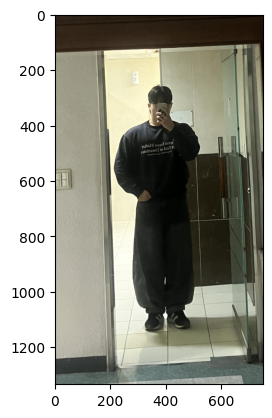

In [6]:
home_dir = os.getenv('HOME')
img_path = os.path.join(home_dir, '/content/human_segmentation/images/sung.png')
img_orig = cv2.imread(img_path)

print(f'이미지 크기 : {img_orig.shape}')

plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

In [10]:
model = deeplabv3_resnet101(pretrained=True).eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:00<00:00, 413MB/s]


In [9]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((512, 512)),
    T.ToTensor()
])

In [10]:
input_tensor = transform(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [11]:
%%time

with torch.no_grad():
  output = model(input_tensor)['out'][0]
  output_predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (img_orig.shape[1], img_orig.shape[0]), interpolation=cv2.INTER_NEAREST )

CPU times: user 7.65 s, sys: 377 ms, total: 8.03 s
Wall time: 1.6 s


In [11]:
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

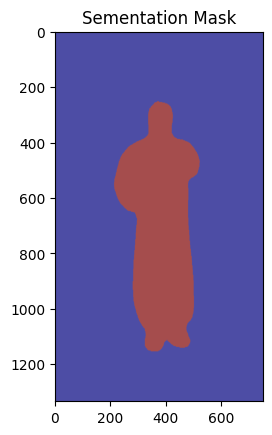

In [13]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Sementation Mask")
plt.show()

In [14]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0, 15], dtype=uint8)

In [15]:
for class_id in unique_classes:
  print(LABEL_NAMES[class_id])

background
person


In [16]:
colormap = np.zeros((256, 3), dtype=int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
  for channel in range(3):
    colormap[:, channel] |= ((ind >> channel) & 1) << shift
  ind >>= 3

colormap[:20]

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

In [18]:
colormap[15]

array([192, 128, 128])

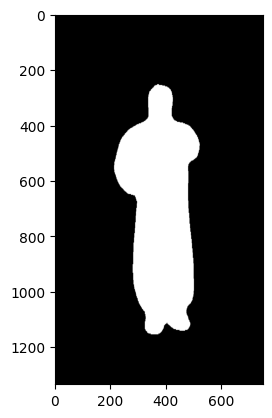

In [19]:
seg_map = (output_predictions_resized == unique_classes[-1])
img_mask = seg_map.astype(np.uint8) * 255
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')
plt.show()

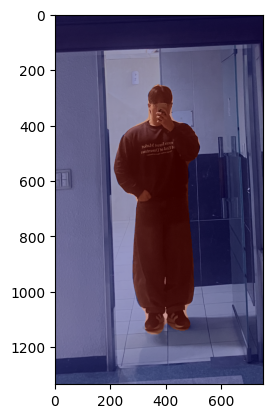

In [20]:
img_show = cv2.addWeighted(img_orig, 0.6, color_mask, 0.4, 0)
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

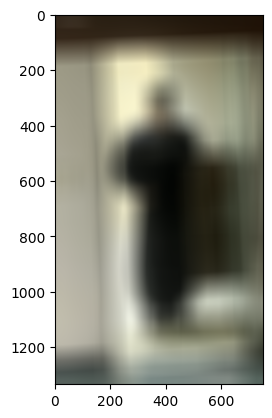

In [26]:
img_orig_blur = cv2.blur(img_orig, (100, 100))

plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

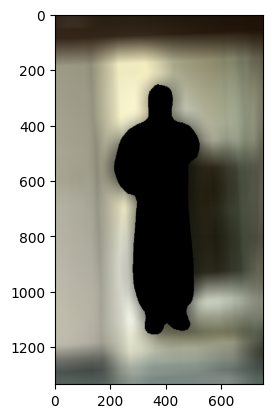

In [27]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

img_bg_mask = cv2.bitwise_not(img_mask_color)

img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

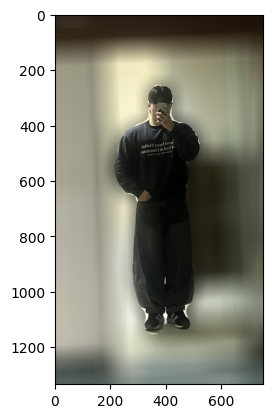

In [28]:
img_concat = np.where(img_mask_color == 255, img_orig, img_bg_blur)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

## -----------------------------------------------------------------

## 동물 사진

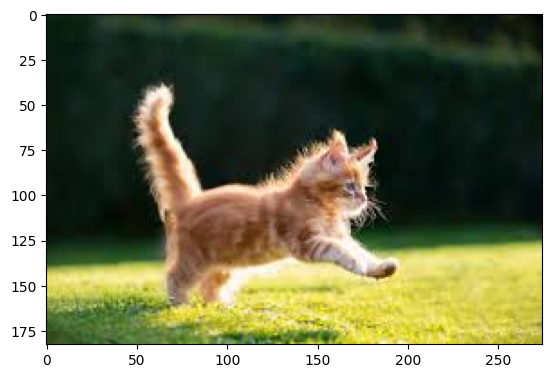

In [7]:
cat_path = os.path.join(home_dir, '/content/human_segmentation/images/cat.jpeg')
cat_orig = cv2.imread(cat_path)

plt.imshow(cv2.cvtColor(cat_orig, cv2.COLOR_BGR2RGB))
plt.show()

In [22]:
input_cat_tensor = transform(cv2.cvtColor(cat_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

In [23]:
with torch.no_grad():
  output_cat = model(input_cat_tensor)['out'][0]
  output_predictions_cat = output_cat.argmax(0).byte().cpu().numpy()

output_predictions_cat_resized = cv2.resize(output_predictions_cat, (cat_orig.shape[1], cat_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

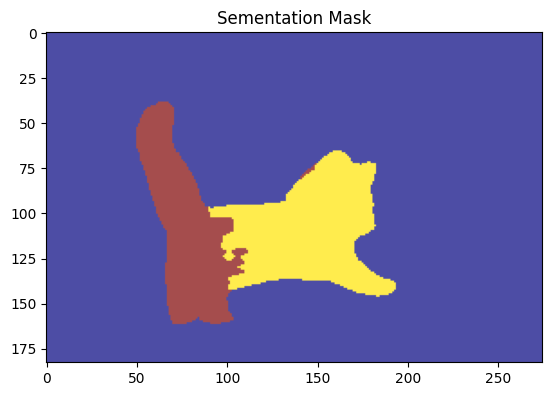

In [24]:
plt.imshow(output_predictions_cat_resized, cmap="jet", alpha=0.7)
plt.title("Sementation Mask")
plt.show()

In [25]:
unique_classes = np.unique(output_predictions_cat_resized)
unique_classes

array([ 0,  8, 12], dtype=uint8)

## 고양이 사진인데 이 부분에서 강아지로 인식함
## 이유가 뭘까?

In [16]:
for class_id in unique_classes:
  print(LABEL_NAMES[class_id])

background
cat
dog


## 강아지로 인식한 부분

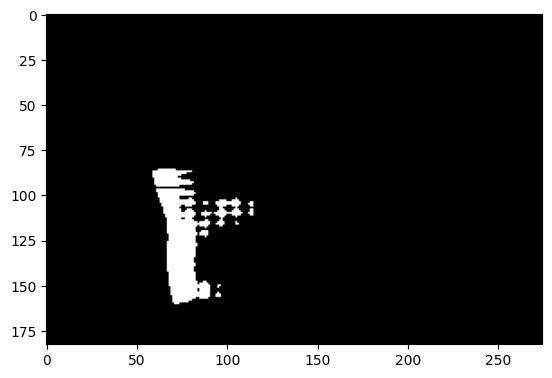

In [17]:
seg_map_cat = (output_predictions_cat_resized == unique_classes[-1])
img_mask = seg_map_cat.astype(np.uint8) * 255
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')
plt.show()

## 정상적인 고양이로 인식한 부분

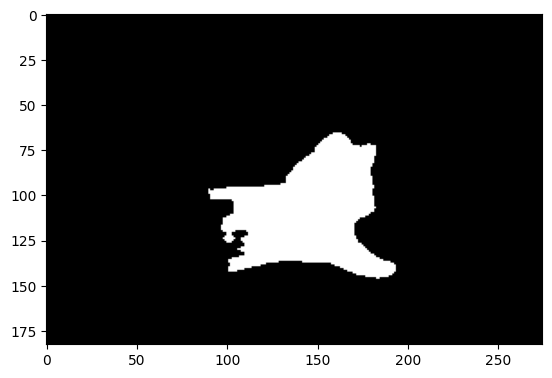

In [26]:
seg_map_cat = (output_predictions_cat_resized == unique_classes[-2])
img_mask = seg_map_cat.astype(np.uint8) * 255
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')
plt.show()

## Sol) transform 부분에 정규화를 사용해보자

In [19]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

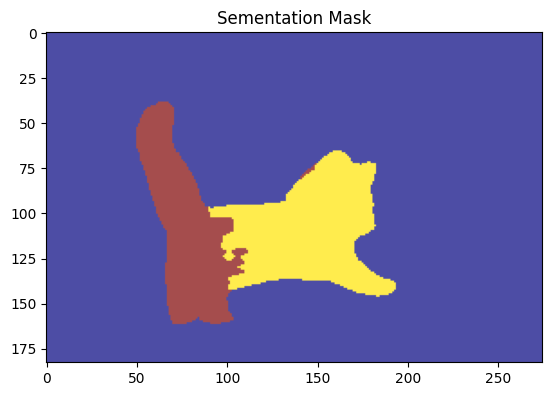

In [20]:
input_cat_tensor = transform(cv2.cvtColor(cat_orig, cv2.COLOR_BGR2RGB)).unsqueeze(0)

with torch.no_grad():
  output_cat = model(input_cat_tensor)['out'][0]
  output_predictions_cat = output_cat.argmax(0).byte().cpu().numpy()

output_predictions_cat_resized = cv2.resize(output_predictions_cat, (cat_orig.shape[1], cat_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

plt.imshow(output_predictions_cat_resized, cmap="jet", alpha=0.7)
plt.title("Sementation Mask")
plt.show()

In [21]:
unique_classes = np.unique(output_predictions_cat_resized)
unique_classes

array([ 0,  8, 12], dtype=uint8)

## 음 그만 알아보자

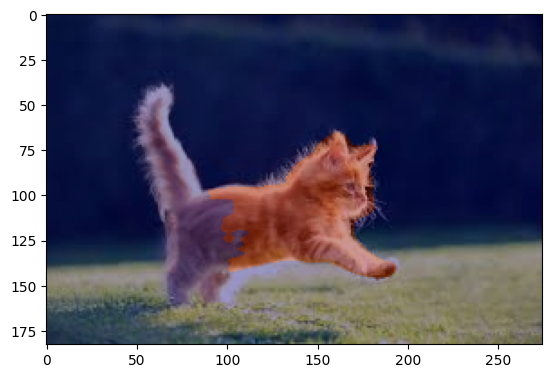

In [27]:
img_show_cat = cv2.addWeighted(cat_orig, 0.6, color_mask, 0.4, 0)

plt.imshow(cv2.cvtColor(img_show_cat, cv2.COLOR_BGR2RGB))
plt.show()

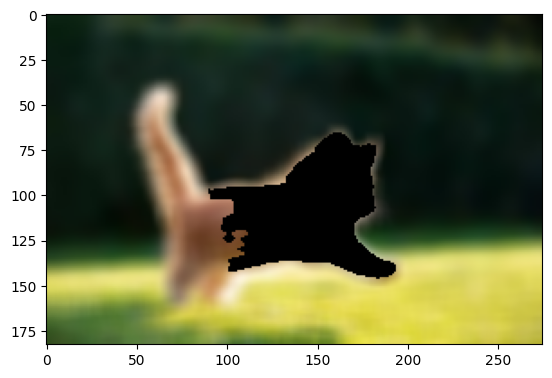

In [28]:
img_orig_blur_cat = cv2.blur(cat_orig, (10, 10))

img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

img_bg_mask = cv2.bitwise_not(img_mask_color)

img_bg_blur = cv2.bitwise_and(img_orig_blur_cat, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

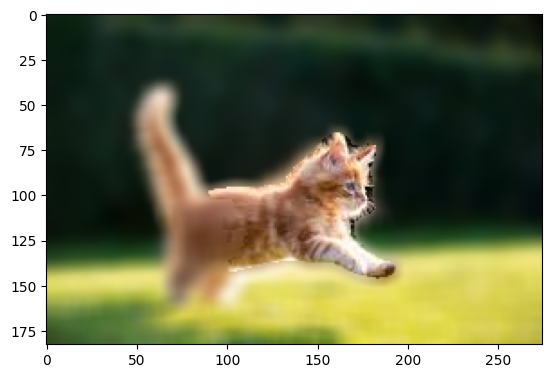

In [29]:
img_concat = np.where(img_mask_color == 255, cat_orig, img_bg_blur)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

## 후처리 기법

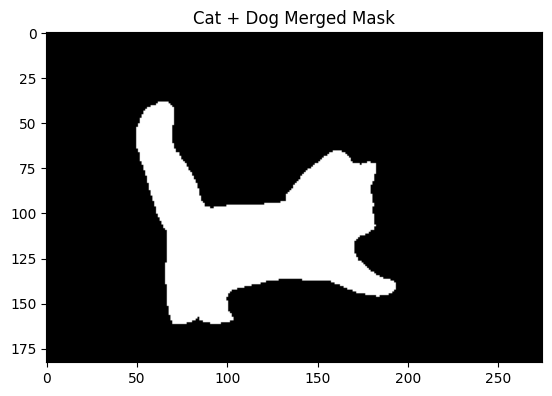

In [32]:
# 모델이 예측한 결과 (output_predictions_resized)에서

CAT_CLASS_ID = 8   # 고양이
DOG_CLASS_ID = 12  # 강아지

# 1. 고양이로 인식된 부분 찾기
mask_cat = (output_predictions_cat_resized == CAT_CLASS_ID)

# 2. 강아지로 인식된 부분 찾기 (실수니깐 이것도 가져와야 함)
mask_dog = (output_predictions_cat_resized == DOG_CLASS_ID)

# 3. [핵심] 두 마스크를 합칩니다 (Logical OR 연산)
final_mask = np.logical_or(mask_cat, mask_dog)

# 4. 정수형으로 변환 (True -> 255, False -> 0)
img_mask = final_mask.astype(np.uint8) * 255

color_mask_1 = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

# 시각화
plt.imshow(img_mask, cmap='gray')
plt.title("Cat + Dog Merged Mask")
plt.show()

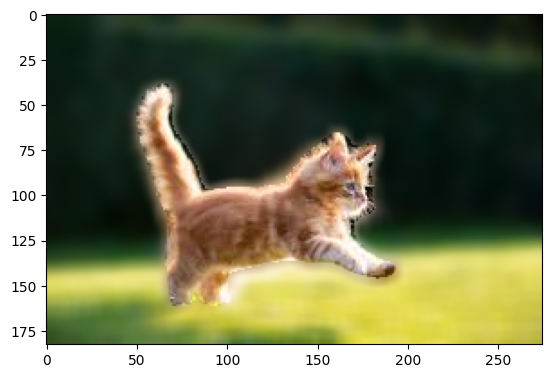

In [39]:
img_show = cv2.addWeighted(cat_orig, 0.6, color_mask_1, 0.4, 0.0)

img_cat_blur = cv2.blur(cat_orig, (10, 10))

img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

img_bg_mask = cv2.bitwise_not(img_mask_color)

img_bg_blur = cv2.bitwise_and(img_cat_blur, img_bg_mask)

img_concat = np.where(img_mask_color == 255, cat_orig, img_bg_blur)

plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

## 배경전환 크로마키사진

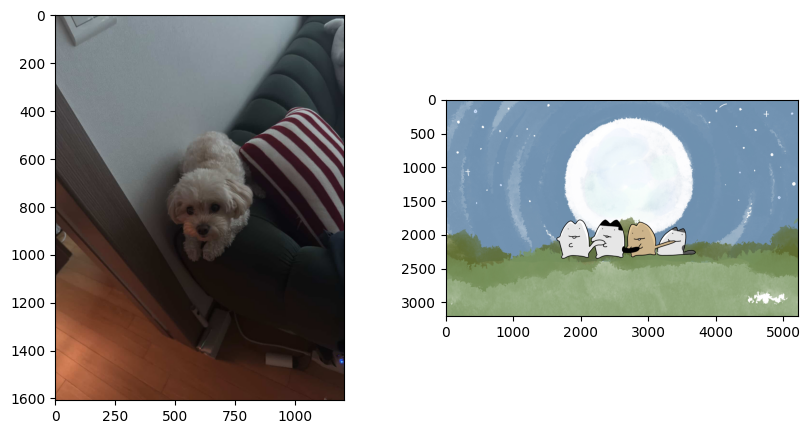

In [108]:
dog_img_path = "/content/human_segmentation/images/dog.jpeg"
back_img_path = "/content/human_segmentation/images/background.jpg"

dog_img = cv2.imread(dog_img_path)
back_img = cv2.imread(back_img_path)

dog_img = cv2.cvtColor(dog_img, cv2.COLOR_BGR2RGB)
back_img = cv2.cvtColor(back_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(dog_img)

plt.subplot(1, 2, 2)
plt.imshow(back_img)

In [116]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_tensor_dog = transform(dog_img).unsqueeze(0)

with torch.no_grad():
  output_1 = model(input_tensor_dog)['out'][0]
  output_predictions_dog = output_1.argmax(0).byte().cpu().numpy()

print(f'추론 마스크 크기 (Before Resize): {output_predictions_dog.shape}')

추론 마스크 크기 (Before Resize): (520, 520)


In [118]:
output_predictions_dog_resized = cv2.resize(output_predictions_dog, (dog_img.shape[1], dog_img.shape[0]), interpolation=cv2.INTER_NEAREST)
print(f'추론 마스크 크기 (After Resize): {output_predictions_dog_resized.shape}')

추론 마스크 크기 (After Resize): (1608, 1206)


In [119]:
unique_classes_dog = np.unique(output_predictions_dog_resized)
print(f'예측된 클래스 ID: {unique_classes_dog}')

예측된 클래스 ID: [ 0  9 12]


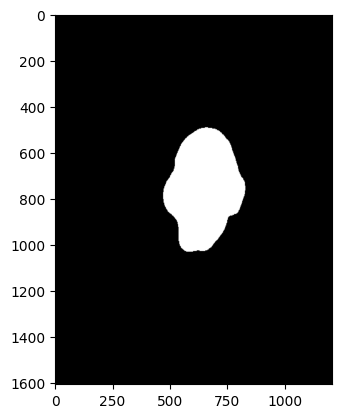

In [122]:
target_class_id = unique_classes_dog[-1]

seg_map_dog = (output_predictions_dog_resized == target_class_id)
img_mask = seg_map_dog.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

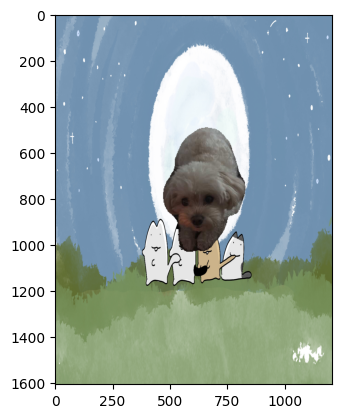

In [124]:
back_img_resized = cv2.resize(back_img, (dog_img.shape[1], dog_img.shape[0]))

img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
result_img = np.where(img_mask_color == 255, dog_img, back_img_resized)

plt.imshow(result_img)
plt.show()

## 회고

## 1. 인물사진 같은 경우 별 문제가 없었으나 동물 사진은 고양이 뒷다리 부분이 강아지로 인식되는 현상이 발생 그래서 솔루션으로 Normalize를 적용해 보았으나 오히려 강아지 뒷다리 인식 면적이 더 넓어짐

## 2. 배경전환 크로마키 같은 경우는 오히려 Normalize를 적용하면 의자와 강아지를 인식 잘했지만, Normalize를 적용하지 않을 경우 강아지와 의자를 인식하지 못함

## 다시 고양이이미지부분